# Tugas 6 - Giovani Rahadian Arif
Tema: Kesesuaian Lahan Agroforestri Kopi Arabika di Kabupaten Bandung Barat

Parameter: 

Tutupan Lahan: (Sumber Data: GeoMAPID)

Fungsi Kawasan: (Sumber Data: KLHK --> Belum ada data fungsi kawasan hutan dalam platform GeoMAPID)

Pengolahan dilakukan di QGIS untuk memberikan kelas kepada masing-masing tutupan dan fungsi kawasan kemudian di unggah ke dalam platform GeoMAPID untuk mendapatkan URL API

In [2]:
import os
import geopandas as gpd
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
#URL API
urls ={
    "Fungsi Kawasan" : "https://geoserver.mapid.io/layers_new/get_layer?api_key=9e69fdfa81594cfea8c1cc383ead7c55&layer_id=68af3992ef2411f2c7b72b4c&project_id=68aaa15d1457f2c845622130&limit=10000",
    "Tutupan Lahan" : "https://geoserver.mapid.io/layers_new/get_layer?api_key=9e69fdfa81594cfea8c1cc383ead7c55&layer_id=68af3798abcfc44262fbe2eb&project_id=68aaa15d1457f2c845622130&limit=10000",
}

# mengambil data API
def get_data(url, layer_name):
    response = requests.get(url)
    if response.status_code == 200:
        geojson_data = response.json()
        gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])

        # Menambahkan kolom SKOR di masing-masing layer API
        if layer_name == "Fungsi Kawasan":
            gdf["SKOR_FUNGSIKWS"]=gdf.get("KELAS_FUNGSIKWS", "").str.upper().map({"TINGGI":3, "SEDANG":2, "RENDAH":1 }).fillna(0)
        elif layer_name == "Tutupan Lahan":
            gdf["SKOR_TUPLAH"]=gdf.get("KESESUAIAN_TUPLAH", "").str.upper().map({"SESUAI":3, "CUKUP SESUAI":2, "TIDAK SESUAI":1 }).fillna(0)
        return gdf
    return gpd.GeoDataFrame()

#Ambil data untuk semua layer
gdf_fkws = get_data(urls["Fungsi Kawasan"], "Fungsi Kawasan")
gdf_tuplah = get_data(urls["Tutupan Lahan"], "Tutupan Lahan")

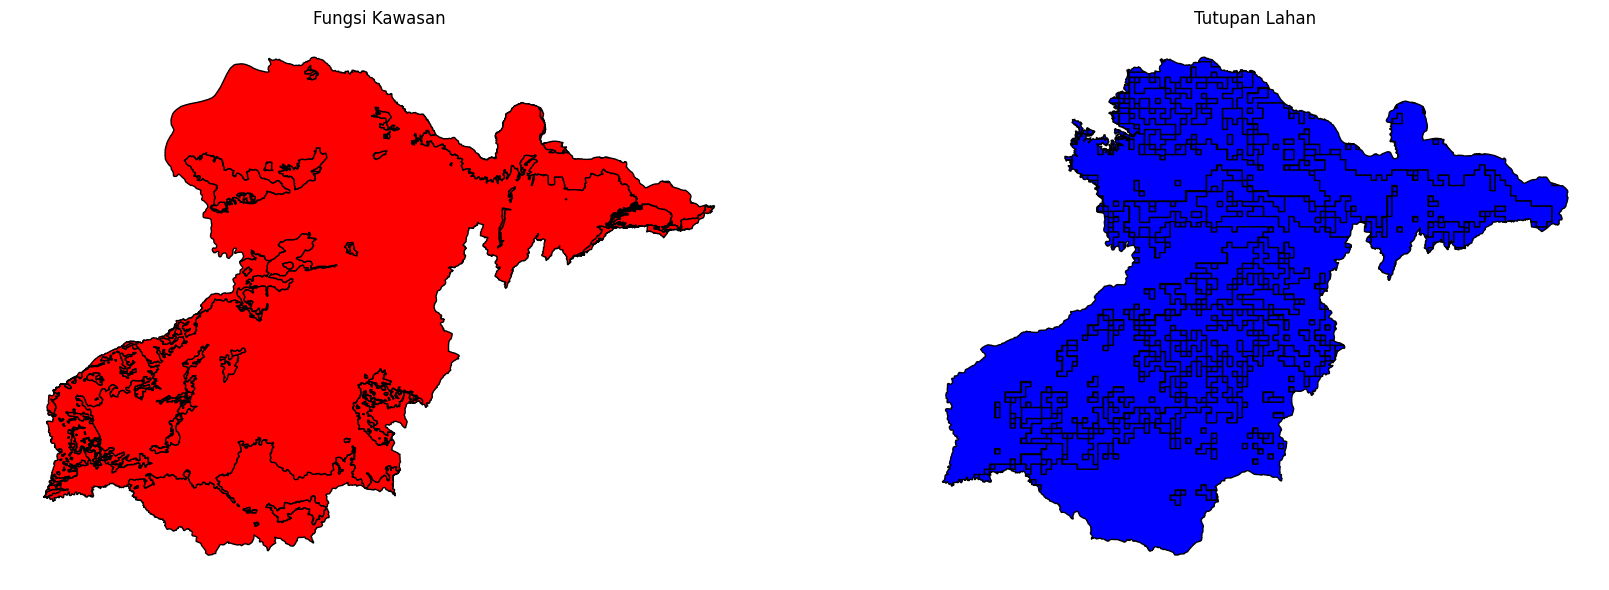

In [17]:
# Visualisasi data variabel
def visualize_data (gdfs):
    fig, axes = plt.subplots(1, len(gdfs), figsize= (18, 6))
    color_map = ['red', 'blue']
    for ax, (name, gdf), color in zip (axes, gdfs.items(), color_map):
        gdf.plot(ax=ax, color=color, edgecolor='black')
        ax.set_title(name)
        ax.set_axis_off()
    plt.tight_layout()
    plt.show

# Menampilkan Visualisasi Data
visualize_data({"Fungsi Kawasan": gdf_fkws, "Tutupan Lahan": gdf_tuplah})


In [20]:
#Handling Null
gdf_fkws['SKOR_FUNGSIKWS'] = gdf_fkws['SKOR_FUNGSIKWS'].fillna(0)
gdf_tuplah['SKOR_TUPLAH'] = gdf_tuplah['SKOR_TUPLAH'].fillna(0)

#Intersection
intersect_gdf = gdf_fkws
if not gdf_tuplah.empty:
    intersect_gdf = gpd.overlay(intersect_gdf, gdf_tuplah, how='intersection', keep_geom_type=False)

#Geometry Fix
intersect_gdf =intersect_gdf[intersect_gdf.is_valid]
intersect_gdf['geometry']=intersect_gdf['geometry'].apply(lambda x: x.make_valid() if not x.is_valid else x)

# perbaikan nilai null pasca intersect
intersect_gdf['SKOR_FUNGSIKWS']=intersect_gdf['SKOR_FUNGSIKWS'].fillna(0)
intersect_gdf['SKOR_TUPLAH']=intersect_gdf['SKOR_TUPLAH'].fillna(0)

#SKOR TOTAL
intersect_gdf['SKOR_TOTAL']=intersect_gdf['SKOR_FUNGSIKWS'] + intersect_gdf['SKOR_TUPLAH']

#Klasifikasi kesesuaian lahan
intersect_gdf['KESESUAIAN_LAHAN']=pd.cut(
    intersect_gdf['SKOR_TOTAL'],
    bins=[1, 2, 4, 6],
    labels=['RENDAH','SEDANG', 'TINGGI'],
    include_lowest=True
)

print(intersect_gdf[['SKOR_FUNGSIKWS','SKOR_TUPLAH','SKOR_TOTAL','KESESUAIAN_LAHAN']].head(10))

   SKOR_FUNGSIKWS  SKOR_TUPLAH  SKOR_TOTAL KESESUAIAN_LAHAN
0               3            3           6           TINGGI
1               1            3           4           SEDANG
2               1            3           4           SEDANG
3               1            1           2           RENDAH
4               1            1           2           RENDAH
5               1            3           4           SEDANG
6               1            1           2           RENDAH
7               3            3           6           TINGGI
8               1            1           2           RENDAH
9               1            2           3           SEDANG


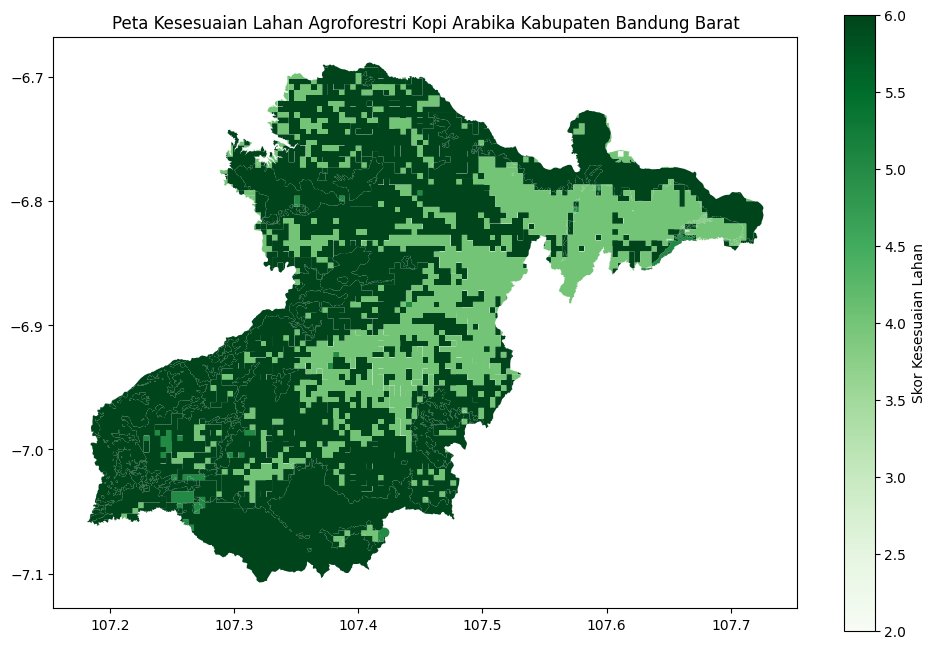

In [29]:
#PETA KESESUAIAN LAHAN
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
intersect_gdf.plot(column='SKOR_TOTAL', cmap='Greens', legend=True, ax=ax, 
legend_kwds={'label': "Skor Kesesuaian Lahan", 'orientation': 
"vertical"})
# Judul dan Label
plt.title('Peta Kesesuaian Lahan Agroforestri Kopi Arabika Kabupaten Bandung Barat')
plt.show()

In [28]:
#Save to geojson

import os

output_dir = r"D:\Bootcamp\Bootcamp WEBGIS Mapid\Tugas 6"
os.makedirs(output_dir, exist_ok=True)

#Save Multipolygon dan Polygon
intersect_gdf_polygon = intersect_gdf[intersect_gdf.geometry.type.isin(['polygon','MultiPolygon'])]

#Geometry Fix
intersect_gdf_polygon['geometry']=intersect_gdf_polygon['geometry'].apply(lambda x: x.make_valid() if not x.is_valid else x)

#Save data
intersect_gdf_polygon.to_file(os.path.join(output_dir, "Giovani Rahadian Arif_Hasil Intersect.geojson"), driver='GeoJSON')

print (f"Data Saved Succesfully! Location: {output_dir}")

c:\Users\giova\AppData\Local\Programs\Python\Python313\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\giova\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


Data Saved Succesfully! Location: D:\Bootcamp\Bootcamp WEBGIS Mapid\Tugas 6
